# Análisis exploratorio de datos (EDA) - Detección de Fraude

In [1]:
# Importamos librerias a utilizar
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import gc
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
import numpy as np

In [2]:
# importamos datos Train Transaction
filename = 'C:/Users/luis_/Desktop/MaestriaEstadisticaAplicada/_8MachineLearning/parcial_practico/fraude/train_transaction.csv'
train_transaction = pd.read_csv(filename)

# importamos datos Train Identity
filename = 'C:/Users/luis_/Desktop/MaestriaEstadisticaAplicada/_8MachineLearning/parcial_practico/fraude/train_identity.csv'
train_identity = pd.read_csv(filename)

# importamos datos Test Transaction
filename = 'C:/Users/luis_/Desktop/MaestriaEstadisticaAplicada/_8MachineLearning/parcial_practico/fraude/test_transaction.csv'
test_transaction = pd.read_csv(filename)

# importamos datos Train Transaction
filename = 'C:/Users/luis_/Desktop/MaestriaEstadisticaAplicada/_8MachineLearning/parcial_practico/fraude/test_identity.csv'
test_identity = pd.read_csv(filename)

In [3]:
# Unión de las bases
train_data = pd.merge(train_transaction, train_identity, on='TransactionID', how='left')
test_data = pd.merge(test_transaction, test_identity, on='TransactionID', how='left')

## Descripción de los datos

El conjunto de datos corresponde a transacciones de hechas por tarjetas de crédito, las cuales algunas son fraudulentas. El conjunto de datos como se puede ver en la tabla de abajo contine información como el monto de la transacción, método de pago, tipo de producto, datos del dispositivo utilizado, así como datos del usuario.

El objetivo de este trabajo es construir un modelo de clasificación binaria que prediga si en una transacción ocurrió o no fraude. 

| Variable        | Abreviación   | Descripción                                                      |
|-----------------|---------------|------------------------------------------------------------------|
| **isFraud**     | isFraud       | Indicador de fraude (1: fraude, 0: no fraude).                  |
| TransactionID   | TransID       | ID única de la transacción.                                      |
| TransactionDT   | TransDT       | Tiempo desde el inicio de los datos (en segundos).               |
| TransactionAmt  | TransAmt      | Monto de la transacción.                                         |
| ProductCD       | ProdCD        | Código del tipo de producto financiero.                         |
| card1           | card1         | Identificador parcial del titular de la tarjeta.                |
| card2           | card2         | Posible banco emisor de la tarjeta.                             |
| card3           | card3         | Región del emisor de la tarjeta.                                |
| card4           | card4         | Tipo de tarjeta (Visa, MasterCard, etc.).                       |
| card5           | card5         | Código del banco emisor.                                        |
| card6           | card6         | Tipo de cuenta (crédito, débito).                               |
| addr1           | addr1         | Código de región del comprador.                                 |
| addr2           | addr2         | Zona más específica (posiblemente país).                        |
| dist1           | dist1         | Distancia entre comprador y comerciante (posiblemente geográfica). |
| dist2           | dist2         | Otra medida de distancia (más específica).                      |
| P_emaildomain  | P_email       | Dominio del correo del comprador.                               |
| R_emaildomain  | R_email       | Dominio del correo del receptor.                                |
| C1-C14          | C1-C14        | Variables agregadas sobre comportamiento del cliente.           |
| D1-D15          | D1-D15        | Variables relacionadas con tiempo desde eventos anteriores.     |
| M1-M9           | M1-M9         | Validaciones binarias (coincidencia de info, navegador, etc.).  |
| V1-V339         | V1-V339       | Variables encriptadas del comportamiento y características del usuario. |
| id_01-id_38     | id_01-id_38   | Variables relacionadas con riesgo, transacción y dispositivo.   |
| DeviceType      | dtype    | Tipo de dispositivo usado (desktop, mobile).                    |
| DeviceInfo      | dinfo    | Información detallada del dispositivo usado.                    |

El objetivo de este trabajo es construir un modelo de clasificación binaria que prediga si en una transacción ocurrió o no fraude. Antes de construir un modelo, se hará un análisis exploratorio de los datos y antes comenzar con el análisis vamos a reducir los nombres extensos de algunas columnas, en la tabla anterior se puede ver la abreviación que se le dará a las columnas.

In [4]:
# Realizamos en cambio de nombre de las columnas
rename_dict = {
    'TransactionID': 'TransID',
    'TransactionDT': 'TransDT',
    'TransactionAmt': 'TransAmt',
    'ProductCD': 'ProdCD',
    'P_emaildomain': 'P_email',
    'R_emaildomain': 'R_email',
    'DeviceType': 'dtype',
    'DeviceInfo': 'dinfo',
}

train_data.rename(columns=rename_dict, inplace=True)
test_data.rename(columns=rename_dict, inplace=True)

In [5]:
train_data.head()

,TransID,isFraud,TransDT,TransAmt,ProdCD,card1,card2,card3,card4,card5,...,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,dtype,dinfo
0,2987000,0,86400,68.5,W,13926,NaN,150.0,discover,142.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2987002,0,86469,59.0,W,4663,490.0,150.0,visa,166.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2987003,0,86499,50.0,W,18132,567.0,150.0,mastercard,117.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2987004,0,86506,50.0,H,4497,514.0,150.0,mastercard,102.0,...,samsung browser 6.2,32.0,2220x1080,match_status:2,T,F,T,T,mobile,SAMSUNG SM-G892A Build/NRD90M


In [6]:
test_data.head()

,TransID,TransDT,TransAmt,ProdCD,card1,card2,card3,card4,card5,card6,...,id-31,id-32,id-33,id-34,id-35,id-36,id-37,id-38,dtype,dinfo
0,3663549,18403224,31.95,W,10409,111.0,150.0,visa,226.0,debit,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,3663550,18403263,49.00,W,4272,111.0,150.0,visa,226.0,debit,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,3663551,18403310,171.00,W,4476,574.0,150.0,visa,226.0,debit,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,3663552,18403310,284.95,W,10989,360.0,150.0,visa,166.0,debit,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,3663553,18403317,67.95,W,18018,452.0,150.0,mastercard,117.0,debit,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Luego de haber realizado el cambio de nombres podemos comenzar con el análisis de los datos. Solo se hará el análisis a los datos de entrenamiento, ya que los datos de prueba no cuentan con la columna de respuesta 'isFraud' por lo que no la podremos utilizar en el modelo.

## Análisis Train Data 

### Estadisticas descriptivas

In [7]:
# Inspección general
train_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 590540 entries, 0 to 590539
Columns: 434 entries, TransID to dinfo
dtypes: float64(399), int64(4), object(31)
memory usage: 1.9+ GB


Vemos que el conjunto de entrenamiento cuenta con 590540 filas y 434 columnas. De las columnas 399 cuentan con datos decimales, 4 con enteros y 31 con datos tipo texto.

In [ ]:
# Estadisticas descriptivas de las variables.
train_data.describe()

,TransID,isFraud,TransDT,TransAmt,card1,card2,card3,card5,addr1,addr2,...,id_17,id_18,id_19,id_20,id_21,id_22,id_24,id_25,id_26,id_32
count,5.905400e+05,590540.000000,5.905400e+05,590540.000000,590540.000000,581607.000000,588975.000000,586281.000000,524834.000000,524834.000000,...,139369.000000,45113.000000,139318.000000,139261.000000,5159.000000,5169.000000,4747.000000,5132.000000,5163.000000,77586.000000
mean,3.282270e+06,0.034990,7.372311e+06,135.027176,9898.734658,362.555488,153.194925,199.278897,290.733794,86.800630,...,189.451377,14.237337,353.128174,403.882666,368.269820,16.002708,12.800927,329.608924,149.070308,26.508597
std,1.704744e+05,0.183755,4.617224e+06,239.162522,4901.170153,157.793246,11.336444,41.244453,101.741072,2.690623,...,30.375360,1.561302,141.095343,152.160327,198.847038,6.897665,2.372447,97.461089,32.101995,3.737502
min,2.987000e+06,0.000000,8.640000e+04,0.251000,1000.000000,100.000000,100.000000,100.000000,100.000000,10.000000,...,100.000000,10.000000,100.000000,100.000000,100.000000,10.000000,11.000000,100.000000,100.000000,0.000000
25%,3.134635e+06,0.000000,3.027058e+06,43.321000,6019.000000,214.000000,150.000000,166.000000,204.000000,87.000000,...,166.000000,13.000000,266.000000,256.000000,252.000000,14.000000,11.000000,321.000000,119.000000,24.000000
50%,3.282270e+06,0.000000,7.306528e+06,68.769000,9678.000000,361.000000,150.000000,226.000000,299.000000,87.000000,...,166.000000,15.000000,341.000000,472.000000,252.000000,14.000000,11.000000,321.000000,149.000000,24.000000
75%,3.429904e+06,0.000000,1.124662e+07,125.000000,14184.000000,512.000000,150.000000,226.000000,330.000000,87.000000,...,225.000000,15.000000,427.000000,533.000000,486.500000,14.000000,15.000000,371.000000,169.000000,32.000000
max,3.577539e+06,1.000000,1.581113e+07,31937.391000,18396.000000,600.000000,231.000000,237.000000,540.000000,102.000000,...,229.000000,29.000000,671.000000,661.000000,854.000000,44.000000,26.000000,548.000000,216.000000,32.000000


In [10]:
# Separar tipos
categorical_cols = train_data.select_dtypes(include=['object', 'category']).columns
binary_cols = [col for col in train_data.columns
               if train_data[col].nunique() <= 2 and pd.api.types.is_numeric_dtype(train_data[col])]
numeric_cols = [col for col in train_data.select_dtypes(include=[np.number]).columns
                if col not in binary_cols]

# Estadísticas descriptivas
print("Estadísticas numéricas continuas:")
print(train_data[numeric_cols].describe())

print("Variables binarias (0/1):")
print(train_data[binary_cols].mean().rename("Proporción de 1s"))

print("Frecuencias de variables categóricas:")
for col in categorical_cols:
    print(f"\nColumna: {col}")
    print(train_data[col].value_counts(dropna=False).head(5))  # Top 5 categorías (incluye NaN)

Estadísticas numéricas continuas:
            TransID       TransDT       TransAmt          card1  \
count  5.905400e+05  5.905400e+05  590540.000000  590540.000000   
mean   3.282270e+06  7.372311e+06     135.027176    9898.734658   
std    1.704744e+05  4.617224e+06     239.162522    4901.170153   
min    2.987000e+06  8.640000e+04       0.251000    1000.000000   
25%    3.134635e+06  3.027058e+06      43.321000    6019.000000   
50%    3.282270e+06  7.306528e+06      68.769000    9678.000000   
75%    3.429904e+06  1.124662e+07     125.000000   14184.000000   
max    3.577539e+06  1.581113e+07   31937.391000   18396.000000   

               card2          card3          card5          addr1  \
count  581607.000000  588975.000000  586281.000000  524834.000000   
mean      362.555488     153.194925     199.278897     290.733794   
std       157.793246      11.336444      41.244453     101.741072   
min       100.000000     100.000000     100.000000     100.000000   
25%       214.000

* La variable de respuesta isFraud tiene el 3.5% de sus observaciones como 1, lo que corresponde a 20663 observaciones, y el resto como 0, lo que indica que hay un desbalance en el conjunto de datos.

* Para el monto de la transacción vemos que la medio es de 135, con valor mínimo de 0.35 y máximo de 31937, lo que indica una cola larga a la derecha, es decir una distribución asimétrica positiva.

* La variable de card4, la cual corresponde al tipo de tarjeta, muestra que la mayoría de las transacciones, el 65%, fueron realizadas con una tarjeta Visa, seguida de la tarjeta Mastercard. Entre ambas tienen el 96% de las transacciones. Los otros tipos de tarjeta son American Express y Discovery. El número de datos faltantes es alrededor del 0.3%.

* La variable card6, muestra que la mayoría de las tarjetas son debito (74%) y las tarjetas crédito corresponden al 25% de los datos. Hay un par de categorías poco comunes llamadas ‘debit or credit’ y ‘charge card’.

* El dominio más común de correo utilizado por el comprador es Gmail, seguido por Hotmail. El 76% de los datos en esta categoría son faltantes.
Con respecto al sistema operativo (id_30) vemos que dominan Windows 10, Windows 7 Y iOS 11. En esta variable también podemos ver que alrededor del 87% de las observaciones son faltantes.

* El tipo de dispositivo más utilizado para realizar estas transacciones es Desktop con alrededor del 55% de las transacciones y Mobile con el 45%. Aun así, esta columna también cuenta con alrededor del 76% de las observaciones faltantes.

### Datos faltantes

In [18]:
# 1. Conteo de valores faltantes por columna
missing_count = train_data.isna().sum()

# 2. Porcentaje de valores faltantes
missing_percent = (missing_count / len(train_data)) * 100

# 3. DataFrame resumen
missing_df = pd.DataFrame({
    'missing_count': missing_count,
    'missing_percent': missing_percent.round(2)
})

# Filtrar solo las columnas con al menos 1 valor faltante
missing_df = missing_df[missing_df['missing_count'] > 0].sort_values('missing_percent', ascending=False)

print(missing_df)

       missing_count  missing_percent
id_24         585793            99.20
id_07         585385            99.13
id_08         585385            99.13
id_21         585381            99.13
id_26         585377            99.13
...              ...              ...
V285              12             0.00
V284              12             0.00
V280              12             0.00
V279              12             0.00
V312              12             0.00

[414 rows x 2 columns]


In [19]:
print(missing_df.to_markdown())

|         |   missing_count |   missing_percent |
|:--------|----------------:|------------------:|
| id_24   |          585793 |             99.2  |
| id_07   |          585385 |             99.13 |
| id_08   |          585385 |             99.13 |
| id_21   |          585381 |             99.13 |
| id_26   |          585377 |             99.13 |
| id_25   |          585408 |             99.13 |
| id_23   |          585371 |             99.12 |
| id_27   |          585371 |             99.12 |
| id_22   |          585371 |             99.12 |
| dist2   |          552913 |             93.63 |
| D7      |          551623 |             93.41 |
| id_18   |          545427 |             92.36 |
| D13     |          528588 |             89.51 |
| D14     |          528353 |             89.47 |
| D12     |          525823 |             89.04 |
| id_04   |          524216 |             88.77 |
| id_03   |          524216 |             88.77 |
| D6      |          517353 |             87.61 |


Vemos que 414 variables tienen al menos 1 dato faltante, entre esas 208 variables tienen más del 75% de sus datos faltantes. Las más comunes son las variables del tipo Vxxx, id_xx, y Dxx.

### Selección de variables a analizar

Las variables seleccionadas para el análisis son las siguientes:

- isFraud: Transacciones fraudulentas y no fraudulentas
- TransAmt: Monto de la transacción
- card4: Tipo de tarjeta (Visa, MasterCard, etc.)
- card6: Tipo de cuenta (crédito, débito)
- is_30: Sistema operativo del dispositivo electrónico
- DevType: Tipo de dispositivo electrónico

Antes de analizarlas se hará un cambio a la columna id_30 para que sea más fácil su análisis.

In [11]:
# Valores únicos de la columna id_30
unique_values = train_data['id_30'].unique()
print(unique_values)

[nan 'Android 7.0' 'iOS 11.1.2' 'Mac OS X 10_11_6' 'Windows 10' 'Android'
 'Linux' 'iOS 11.0.3' 'Mac OS X 10_7_5' 'Mac OS X 10_12_6'
 'Mac OS X 10_13_1' 'iOS 11.1.0' 'Mac OS X 10_9_5' 'Windows 7'
 'Windows 8.1' 'Mac' 'iOS 10.3.3' 'Mac OS X 10.12' 'Mac OS X 10_10_5'
 'Mac OS X 10_11_5' 'iOS 9.3.5' 'Android 5.1.1' 'Android 7.1.1'
 'Android 6.0' 'iOS 10.3.1' 'Mac OS X 10.9' 'iOS 11.1.1' 'Windows Vista'
 'iOS 10.3.2' 'iOS 11.0.2' 'Mac OS X 10.11' 'Android 8.0.0' 'iOS 10.2.0'
 'iOS 10.2.1' 'iOS 11.0.0' 'Mac OS X 10.10' 'Mac OS X 10_12_3'
 'Mac OS X 10_12' 'Android 6.0.1' 'iOS' 'Mac OS X 10.13'
 'Mac OS X 10_12_5' 'Mac OS X 10_8_5' 'iOS 11.0.1' 'iOS 10.0.2'
 'Android 5.0.2' 'Windows XP' 'iOS 11.2.0' 'Mac OS X 10.6' 'Windows 8'
 'Mac OS X 10_6_8' 'Mac OS X 10_11_4' 'Mac OS X 10_12_1' 'iOS 10.1.1'
 'Mac OS X 10_11_3' 'Mac OS X 10_12_4' 'Mac OS X 10_13_2' 'Android 4.4.2'
 'Mac OS X 10_12_2' 'Android 5.0' 'func' 'Android 7.1.2' 'Android 8.1.0'
 'other' 'Mac OS X 10_13_3' 'iOS 11.2.1' 'iOS 11.2.5

Como podemos ver tiene muchos datos distintos, solo nos interesa el tipo de dispositivo, por lo que crearemos una nueva columna dividiendo id_30 y nos quedándonos solo con la parte inicial. Llamaremos la nueva columns "opsyst".

In [12]:
# Asumiendo que 'id_30' contiene las cadenas que deseas dividir
train_data['opsyst'] = train_data['id_30'].str.split(' ').str[0]

In [13]:
unique_values = train_data['opsyst'].unique()
print(unique_values)

[nan 'Android' 'iOS' 'Mac' 'Windows' 'Linux' 'func' 'other']


Ahora solo quedamos con 7 categorías. A continuación, seleccionamos las variables a utilizar en el análisis y creamos un nuevo dataframe con ellas.

In [14]:
# Seleccionamos las seis variables
var_selected = ['isFraud', 'TransAmt', 'card4', 'card6', 'opsyst', 'dtype']

train_selected = train_data[var_selected]

train_selected.head()

,isFraud,TransAmt,card4,card6,opsyst,dtype
0,0,68.5,discover,credit,NaN,NaN
1,0,29.0,mastercard,credit,NaN,NaN
2,0,59.0,visa,debit,NaN,NaN
3,0,50.0,mastercard,debit,NaN,NaN
4,0,50.0,mastercard,credit,Android,mobile


### Gráficas

c:\Users\luis_\miniconda3\envs\ml_venv\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


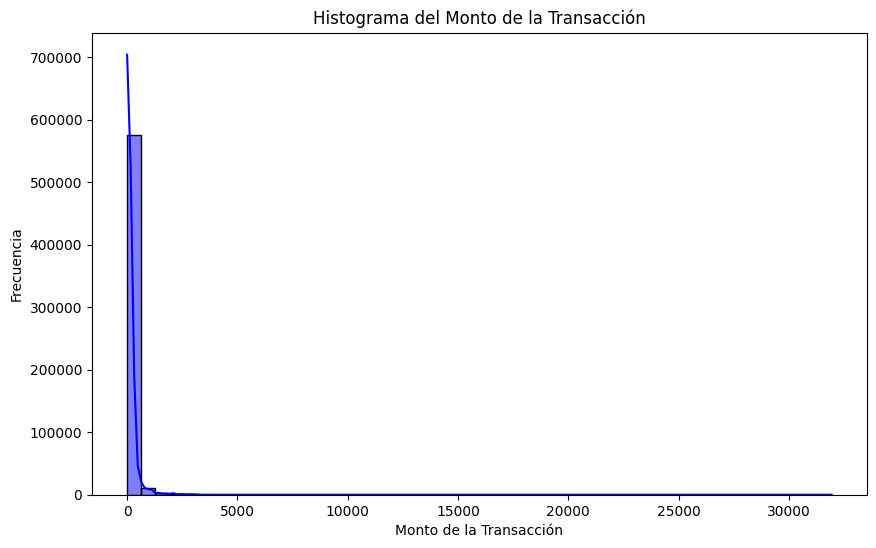

In [33]:
# Histograma del monto de la transacción
plt.figure(figsize=(10, 6))
sns.histplot(train_selected['TransAmt'], kde=True, color='blue', bins=50)
plt.title('Histograma del Monto de la Transacción')
plt.xlabel('Monto de la Transacción')
plt.ylabel('Frecuencia')
plt.show()

La mayoría de los valores están concentrados cerca de 0 y se muestra una larga cola hacia la derecha, lo cual indica valores muy altos como se mencionó anteriormente. El pico más alto ocurre con montos bajos (menos de 100).

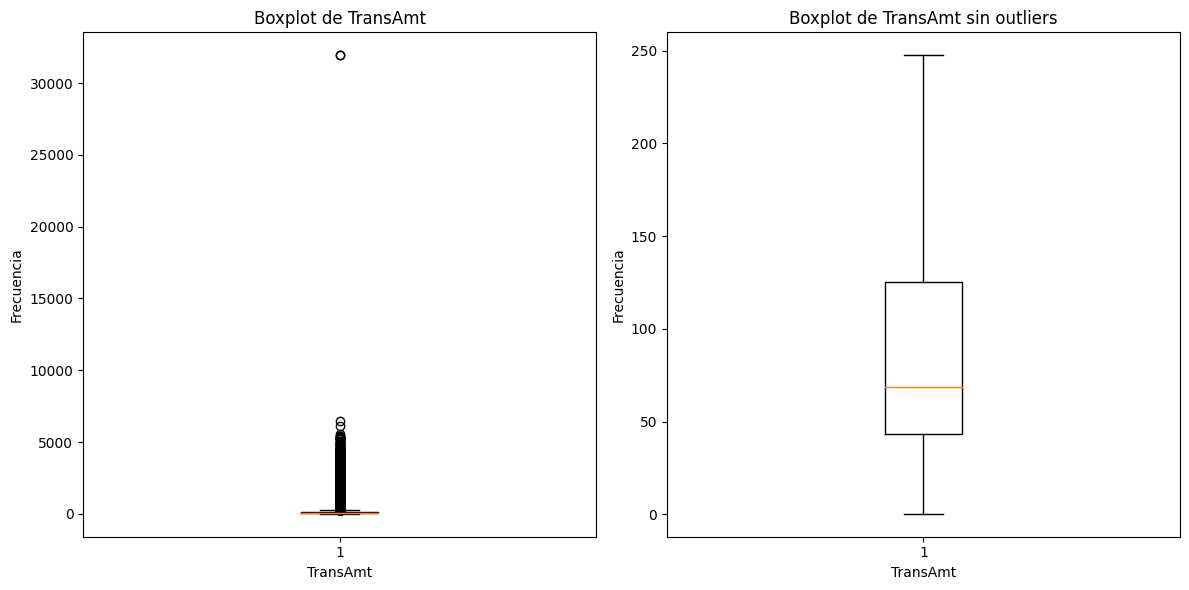

In [49]:
# Preparar los datos para el boxplot con y sin outliers
plt.figure(figsize=(12, 6))

# Boxplot con outliers (mostrar los puntos de los outliers)
plt.subplot(1, 2, 1)
plt.boxplot(x=train_selected['TransAmt'])
plt.title('Boxplot de TransAmt')
plt.xlabel('TransAmt')
plt.ylabel('Frecuencia')

# Boxplot sin outliers (no mostrar los puntos de los outliers)
plt.subplot(1, 2, 2)
plt.boxplot(x=train_selected['TransAmt'], showfliers=False)
plt.title('Boxplot de TransAmt sin outliers')
plt.xlabel('TransAmt')
plt.ylabel('Frecuencia')

plt.tight_layout()  # Ajusta el espaciado entre los subgráficos
plt.show()

* En el grafico de boxplot de la izquierda vemos que hay una gran cantidad de valores atípicos, el rango intercuartil es pequeño en comparación con los valores extremos. Se ve que hay una transacción que supera el monto de 30.000 mientras que la gran mayoría esta por debajo de los 1000.

* En el grafico de la derecha vemos el boxplot sin mostrar los atípicos, vemos que las transacciones más comunes están en el rango de 40 a 130. 

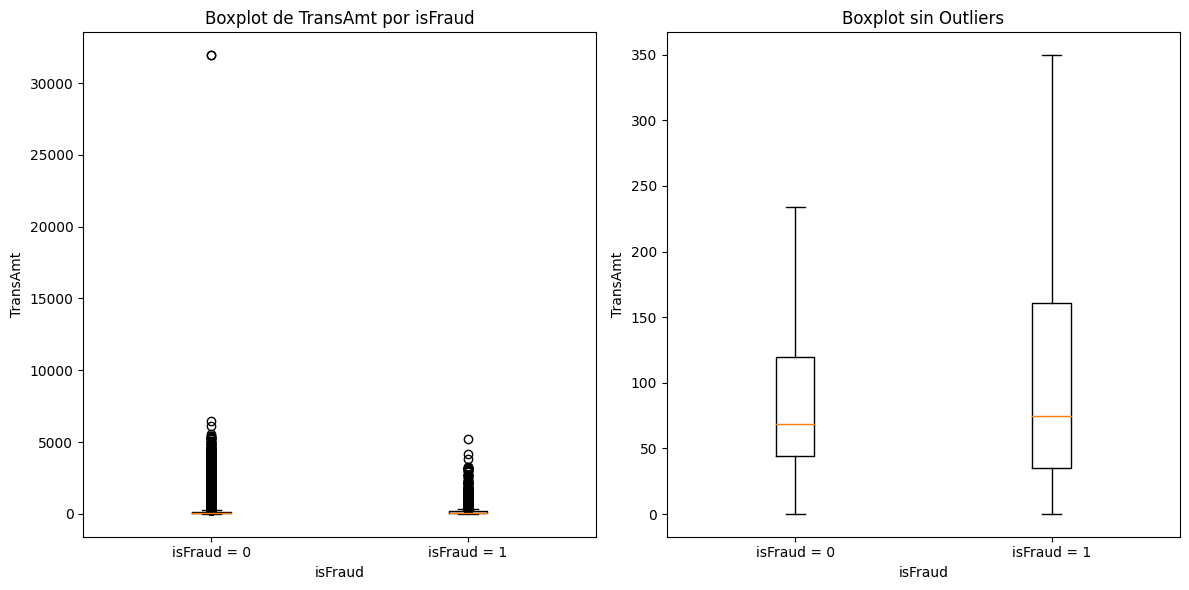

In [ ]:
# Preparar los datos para el boxplot con y sin outliers
plt.figure(figsize=(12, 6))

# Boxplot por variable fraud
data_no_fraud = train_selected.loc[train_selected['isFraud'] == 0, 'TransAmt'].dropna()
data_fraud = train_selected.loc[train_selected['isFraud'] == 1, 'TransAmt'].dropna()

# Boxplot con outliers (mostrar los puntos de los outliers)
plt.subplot(1, 2, 1)
plt.boxplot([data_no_fraud, data_fraud], labels=['isFraud = 0', 'isFraud = 1'])
plt.title('Boxplot de TransAmt por isFraud')
plt.xlabel('isFraud')
plt.ylabel('TransAmt')

# Boxplot sin outliers (no mostrar los puntos de los outliers)
plt.subplot(1, 2, 2)
plt.boxplot([data_no_fraud, data_fraud], labels=['isFraud = 0', 'isFraud = 1'], showfliers=False)
plt.title('Boxplot sin Outliers')
plt.xlabel('isFraud')
plt.ylabel('TransAmt')

plt.tight_layout()  # Ajusta el espaciado entre los subgráficos
plt.show()

* Se observa en el grafico de la izquierda que tanto para isFraud = 0 (sin fraude) como para isFraud = 1 (fraude) hay muchísimos valores atípicos en el monto de la transacción. Vemos que la transacción más alta de aproximadamente 30.000 ocurre cuando no hubo fraude.

* En el grafico de la derecha vemos que cuando no hubo fraude el rango llega a aproximadamente 230 y cuando si hubo este llega a 350. Vemos que la mediana del monto cuando hubo fraude es más alta que en grupo donde no hubo. Esto sugiere que el monto podría ser una variable útil para predecir fraude.

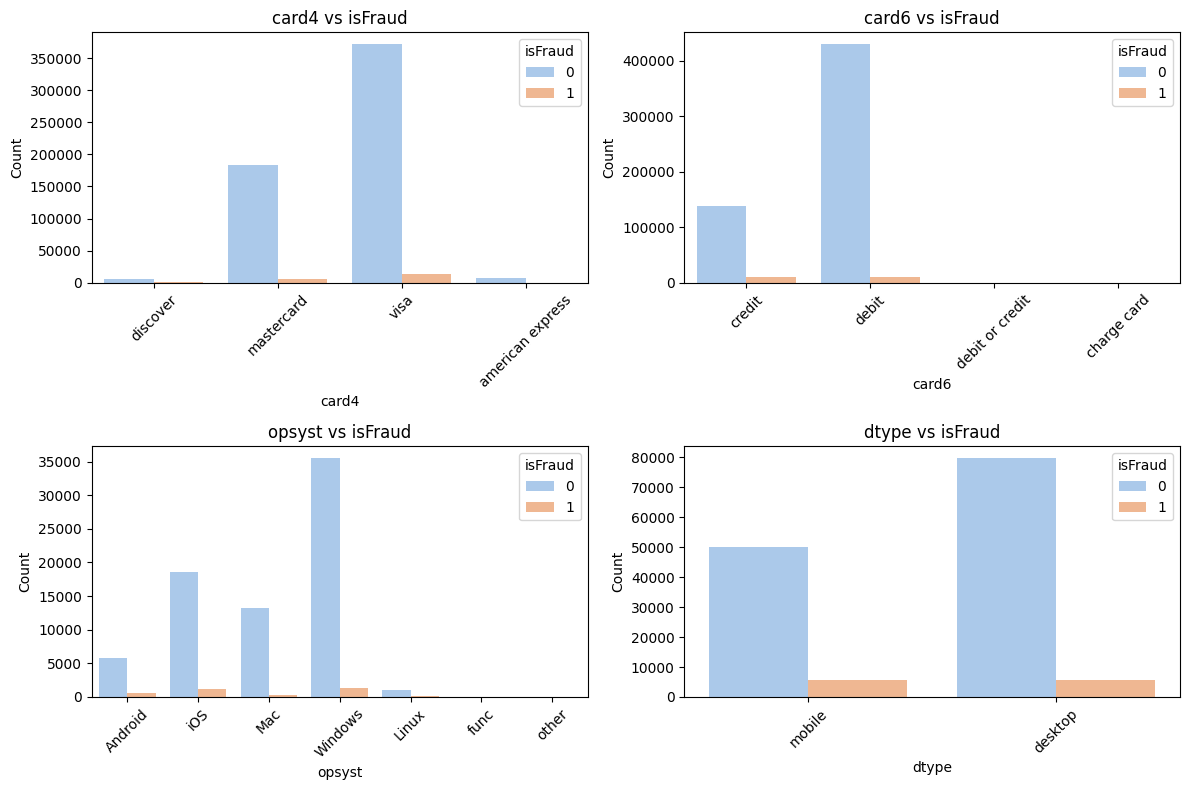

In [52]:
# Lista de columnas categóricas
col = [ 'card4', 'card6', 'opsyst', 'dtype'] 

plt.figure(figsize=(12, 8))

for i, col in enumerate(col, 1):
    plt.subplot(2, 2, i)               # 2 filas x 2 columnas
    sns.countplot(x=col, 
                  hue='isFraud', 
                  data=train_selected, 
                  palette='pastel')
    plt.title(f'{col} vs isFraud')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [15]:
def generar_tabla_con_porcentaje(df, columna, target='isFraud'):
    # Tabla de conteos
    tabla = pd.crosstab(df[columna], df[target])
    
    # Asegurar que existan ambas columnas 0 y 1
    if 0 not in tabla.columns:
        tabla[0] = 0
    if 1 not in tabla.columns:
        tabla[1] = 0
        
    # Calcular % de fraude
    tabla['% fraude'] = tabla[1] / (tabla[0] + tabla[1]) * 100
    
    # Ordenar de mayor a menor % de fraude
    tabla = tabla.sort_values('% fraude', ascending=False)
    
    return tabla

# Generamos las tablas
tablas = {}

for columna in ['card4', 'card6', 'opsyst', 'dtype']:
    tablas[columna] = generar_tabla_con_porcentaje(train_selected, columna)

# Mostrar las tablas
for nombre, tabla in tablas.items():
    print(f"\n--- {nombre} vs isFraud ---")
    print(tabla)


--- card4 vs isFraud ---
isFraud                0      1  % fraude
card4                                    
discover            6137    514  7.728161
visa              371394  13373  3.475610
mastercard        182721   6496  3.433095
american express    8089    239  2.869837

--- card6 vs isFraud ---
isFraud               0      1  % fraude
card6                                   
credit           139036   9950  6.678480
debit            429264  10674  2.426251
charge card          15      0  0.000000
debit or credit      30      0  0.000000

--- opsyst vs isFraud ---
isFraud      0     1   % fraude
opsyst                         
other        6     9  60.000000
Android   5761   542   8.599080
Linux     1051    85   7.482394
iOS      18542  1240   6.268325
Windows  35471  1268   3.451373
Mac      13282   298   2.194404
func        10     0   0.000000

--- dtype vs isFraud ---
isFraud      0     1   % fraude
dtype                          
mobile   49988  5657  10.166232
desktop  7961

* Con respecto a Card4 vs isFraud vemos que Visa y Mastercard son las tarjetas más usadas tanto en fraudes como en transacciones sin fraudes. A pesar de que Visa fue la tarjeta más usada en fraudes, su tasa de fraude relativa no es muy alta. Según la tabla vemos que Discover tiene el % de fraude más alto con el 7.73%, por lo que a pesar de que Visa y Mastercard son las más usadas su porcentaje de fraude es menor, 3.48% y 3.43% respectivamente. Vemos que American Express tiene el porcentaje más bajo con 2.87%. 

* Al comparar Card6 vs isFraud vemos que el porcentaje de fraude es mucho más alto en las tarjetas debito con un 6.68% en comparación con las debito con un 2.43%, esto es a pesar de que las tarjetas debito son mucho más utilizadas. En la imagen podemos confirmar esto, el volumen de debito es superior pero el fraude de ambas es muy parecido, por lo que el fraude en crédito es más relevante en proporción.

* Al comparar sistema operativo con el fraude vemos que other tiene el porcentaje más alto 60%, pero esto puede deberse a los pocos datos que hay en esa categoría, 15 en total. Con respecto a los sistemas operativos más usados vemos que Android tiene el porcentaje de fraude más alta con un 8.6%, seguido por Linux (7.6%) y IOS (6.3%). En la imagen y en la tabla vemos que Windows tiene la mayor cantidad de fraudes en general, pero en relación con el volumen de usuarios que usa Windows este porcentaje es relativamente bajo con un 3.45%.

* Con respecto al tipo de dispositivo móvil utilizado, vemos que los que usan mobile son más propensos al fraude a que este tiene un porcentaje de 10.17% en comparación con desktop con 6.52%. Esto también se puede observar en la gráfica, la cantidad de fraudes en ambos dispositivos es muy parecida pero dado que el volumen de móviles es más bajo esto implica una mayor proporción de fraudes.


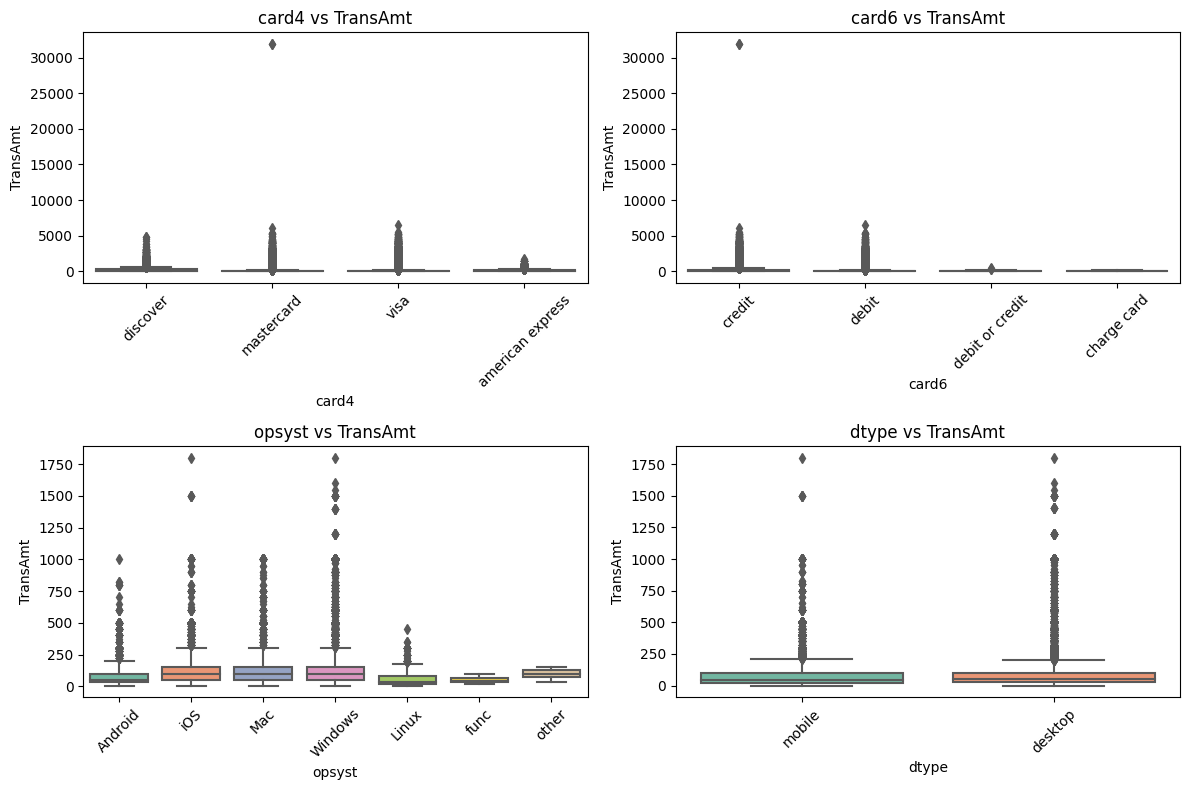

In [55]:
# Definir las variables categóricas a graficar
col = [ 'card4', 'card6', 'opsyst', 'dtype'] 

plt.figure(figsize=(12, 8))

# Loop para generar boxplots por categoría
for i, col in enumerate(col, 1):
    plt.subplot(2, 2, i)               # 2 filas x 2 columnas
    sns.boxplot(x=col, y='TransAmt', data=train_selected, palette='Set2')
    plt.title(f'{col} vs TransAmt')
    plt.xlabel(col)
    plt.ylabel('TransAmt')
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

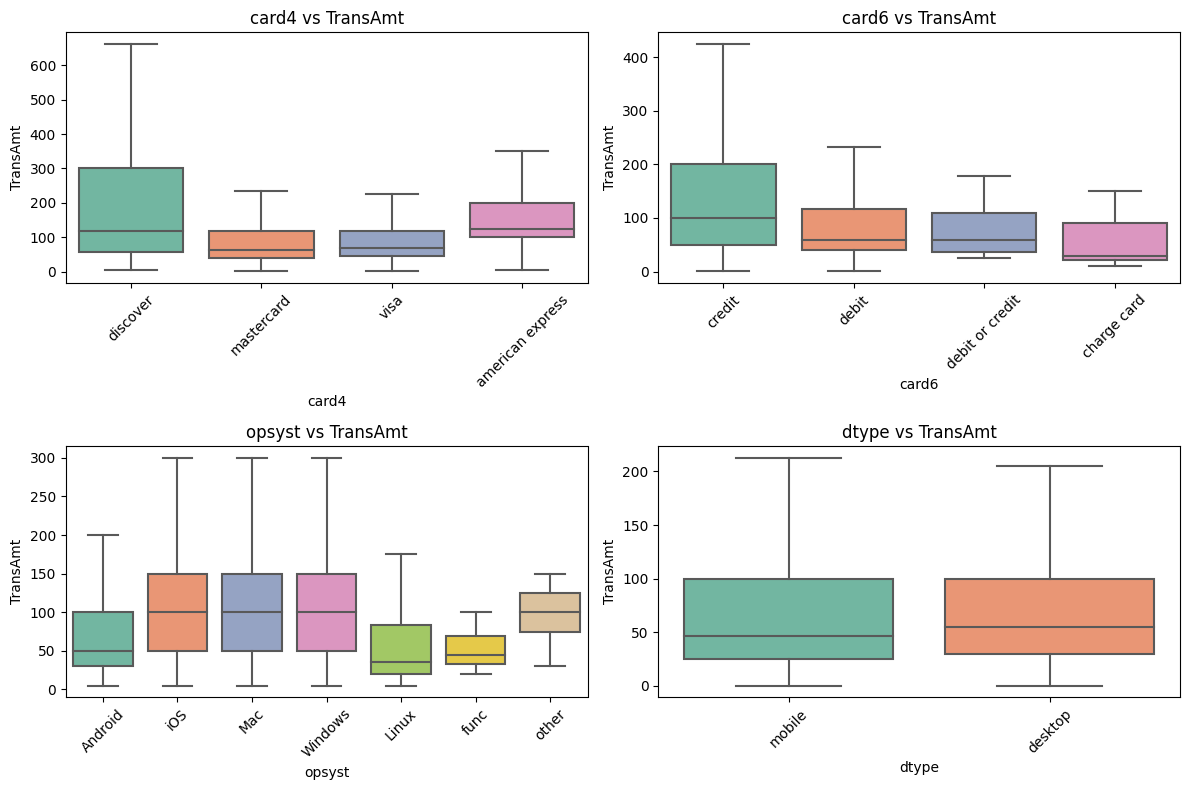

In [54]:
# Definir las variables categóricas a graficar
col = [ 'card4', 'card6', 'opsyst', 'dtype'] 

plt.figure(figsize=(12, 8))

# Loop para generar boxplots por categoría
for i, col in enumerate(col, 1):
    plt.subplot(2, 2, i)               # 2 filas x 2 columnas
    sns.boxplot(x=col, y='TransAmt', data=train_selected, palette='Set2', showfliers=False)
    plt.title(f'{col} vs TransAmt')
    plt.xlabel(col)
    plt.ylabel('TransAmt')
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

* En el grafico de caja y bigote de Card4 y el monto vemos que Discovery tiene las transacciones más altas y dispersas seguido por American Express. Visa y Mastercard tienen montos muy similares y en valores bajos-medios.

* En el grafico de card6 y monto de la transacción vemos que las tarjetas de crédito tienen mayores montos de transacción en comparación con las tarjetas débito, las cuales tienen montos más bajos y una menor dispersión.

* Con respecto al sistema operativo, Mac, iOS y Windows tienen montos promedio más altos, mientras que Linux y Android tienen montos más bajos y menos dispersión.

* Por último, con respecto al tipo de dispositivo, ambos manejan montos muy similares, aunque desktop tiene una media más grande.

## Imputación de datos

Luego de haber realizado los análisis exploratorios realizaremos la imputación de datos faltantes antes de continuar con los modelos. A continuación, se realiza la imputación de los datos faltantes y luego se reduce la dimensionalidad eliminando las columnas altamente correlacionadas, se utilizo un vif mayor a 5 como punto de corte para eliminar las variables.

### Columnas continuas

In [13]:
# Separar columnas numéricas
columnas_numericas = train_data.select_dtypes(include=[np.number]).columns.tolist()
 
# Instanciar el imputador multivariado
imputador =  SimpleImputer(strategy='median')
 
# Ajustar y transformar solo columnas numéricas
train_data[columnas_numericas] = imputador.fit_transform(train_data[columnas_numericas])

In [ ]:
def delete_multicollinearity_superfast(df, target, threshold):
    """
    Removes columns with high Variance Inflation Factor (VIF) to reduce multicollinearity.
    """
    variables = df.drop(columns=[target]).columns
    vif_data = pd.DataFrame()
    vif_data["feature"] = variables
    vif_data["VIF"] = [variance_inflation_factor(df[variables].values, i) for i in range(len(variables))]
    
    # Filter out features with VIF above the threshold
    selected_features = vif_data[vif_data["VIF"] <= threshold]["feature"].tolist()
    return selected_features

def vif_por_bloques(df, target, columnas, block_size=50, threshold=10):
    # Para reducir el tamaño de memoria, convertimos las columnas numéricas a float32 si es posible
    df[columnas] = df[columnas].astype('float32')

    resultado_final = []
    
    # Procesamos los datos en bloques para reducir la carga de memoria
    for i in range(0, len(columnas), block_size):
        subset = columnas[i:i + block_size]
        print(f"\nProcesando bloque {i // block_size + 1}: {subset[0]} → {subset[-1]}")
        
        # Seleccionamos las columnas sin hacer copias innecesarias
        bloque_df = df[subset].copy()  # Si no es necesario hacer una copia, podrías omitir esto
        bloque_df[target] = df[target]
        
        # Llamamos a la función que limpia la multicolinealidad (ajustar según tu lógica)
        limpio = delete_multicollinearity_superfast(bloque_df, target, threshold)
        
        # Añadimos las columnas que pasaron la prueba de VIF
        resultado_final.extend(limpio)
        
        # Liberamos memoria antes de pasar al siguiente bloque
        del bloque_df
        gc.collect()  # Forzamos la recolección de basura para liberar memoria

    return df[resultado_final + [target]]

In [ ]:
# se ejecuta el codigo
df_copy = vif_por_bloques(train_data, target='isFraud', columnas=columnas_numericas, threshold=5)

df_copy.to_csv('data_continua.csv', index=False)

In [64]:
# importamos los datos
filename = 'data_continua.csv'
data_continua = pd.read_csv(filename)

In [65]:
data_continua.head()

,TransAmt,dist1,dist2,C3,D3,D5,D6,D7,D8,D11,...,V325,id_01,id_02,id_03,id_04,id_05,id_06,id_09,id_10,isFraud
0,68.5,19.0,37.0,0.0,13.0,10.0,0.0,0.0,37.875,13.0,...,0.0,-5.0,125800.5,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,29.0,8.0,37.0,0.0,8.0,10.0,0.0,0.0,37.875,43.0,...,0.0,-5.0,125800.5,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,59.0,287.0,37.0,0.0,8.0,10.0,0.0,0.0,37.875,315.0,...,0.0,-5.0,125800.5,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,50.0,8.0,37.0,0.0,0.0,0.0,0.0,0.0,37.875,43.0,...,0.0,-5.0,125800.5,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,50.0,8.0,37.0,0.0,8.0,10.0,0.0,0.0,37.875,43.0,...,0.0,0.0,70787.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


Después de haber realizado el proceso anterior quedan 41 variables continuas, a continuación, se realiza un modelo logístico para determinar las variables más importantes.  

### Modelo logistico para selección de variables

In [66]:
# se crean los conjuntos de prueba y entrenamiento
X_train, X_test, y_train, y_test = train_test_split(data_continua.drop(columns=["isFraud"]), data_continua[["isFraud"]], test_size=0.2, random_state=42)

In [67]:
# modelo logistico
lr_model =LogisticRegression()
lr_model.fit(X_train, y_train)
lr_coef = lr_model.coef_
coef_df = pd.DataFrame({
    'Variable': X_train.columns,
    'Logistic Regression': lr_model.coef_[0]  # coef_[0] es porque devuelve una lista dentro de otra
})

c:\Users\luis_\miniconda3\envs\ml_venv\lib\site-packages\sklearn\utils\validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
c:\Users\luis_\miniconda3\envs\ml_venv\lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


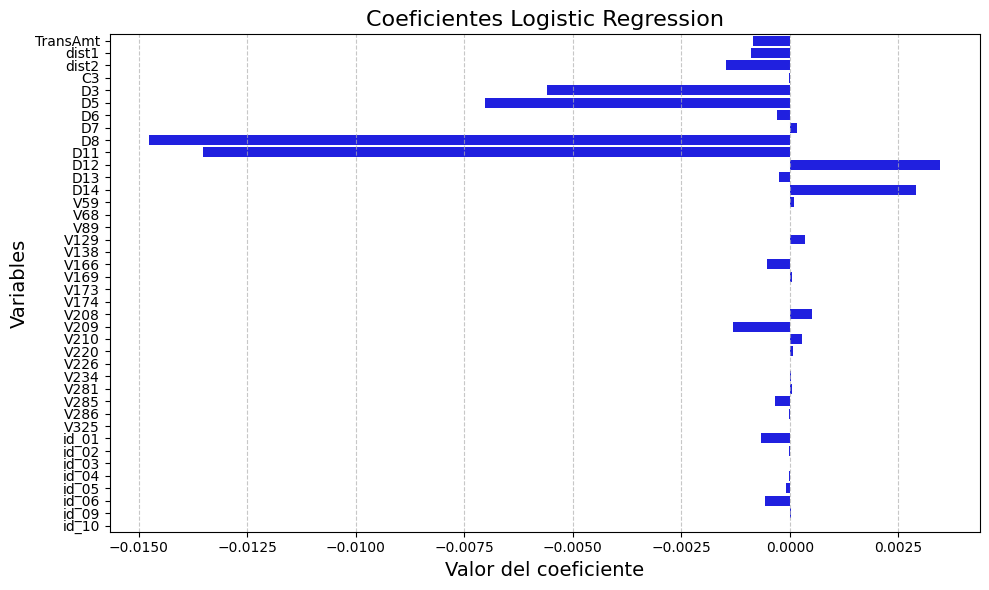

In [68]:
plt.figure(figsize=(10, 6))
sns.barplot(x='Logistic Regression', y='Variable', data=coef_df, color='blue')
plt.title('Coeficientes Logistic Regression', fontsize=16)
plt.xlabel('Valor del coeficiente', fontsize=14)
plt.ylabel('Variables', fontsize=14)
plt.grid(True, axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Se seleccionan las 15 variables que más aportan al modelo como se puede ver en la grafica de coeficientes del modelo logístico. Estas 15 variables continuas se usaran para el entrenamiento de los modelos.

In [69]:
# Lista de las 15 variables con coeficientes más grandes
top_15_vars = [
    'D12', 'D14', 'D11', 'D8', 'TransAmt', 
    'D3', 'D7', 'dist1', 'dist2', 'V209', 
    'V166', 'id_06', 'V285', 'id_01', 'D13'
]

# Filtrar el dataframe original para quedarnos con estas 15 variables más la variable objetivo
# Asumiendo que tu dataframe se llama df_train_ml y la variable objetivo es 'isFraud'
df_reduced = data_continua[top_15_vars + ['isFraud']]

# Verificar las dimensiones
print(f"Dimensiones del dataframe original: {data_continua.shape}")
print(f"Dimensiones del dataframe reducido: {df_reduced.shape}")
print(f"Variables en el nuevo dataframe: {df_reduced.columns.tolist()}")

Dimensiones del dataframe original: (590540, 41)
Dimensiones del dataframe reducido: (590540, 16)
Variables en el nuevo dataframe: ['D12', 'D14', 'D11', 'D8', 'TransAmt', 'D3', 'D7', 'dist1', 'dist2', 'V209', 'V166', 'id_06', 'V285', 'id_01', 'D13', 'isFraud']


Por ultimo se realiza la selección de las variables categóricas, con respecto a las variables categóricas se seleccionaron aquellas que no tenían muchos datos faltantes, ya que la imputación en las variables categóricas no se hace de una manera balanceada como en el caso de las continuas, se suele reemplazar por la categoría más frecuente. Dicho esto, las variables seleccionadas fueron card4 (tipo de tarjeta) y card6 (tipo de producto crédito o débito). Estas variables se les realizara la imputación de datos faltantes y se crearan las variables dummies para poder utilizarlas en el modelo.

### Columnas categoricas

In [71]:
# Separar columnas categoricas
columnas_categoricas = train_data.select_dtypes(include=['object', 'category']).columns.tolist()
 
# Instanciar el imputador multivariado
imputer = SimpleImputer(strategy='most_frequent')
 
# Ajustar y transformar solo columnas numéricas
train_data[columnas_categoricas] = imputer.fit_transform(train_data[columnas_categoricas])

In [73]:
data_cat = train_data[["card4", "card6"]]

In [75]:
data_cat = pd.get_dummies(data_cat, columns=data_cat.columns, drop_first=True)
data_cat.replace({False: 0, True: 1}, inplace=True)

C:\Users\luis_\AppData\Local\Temp\ipykernel_6056\819411780.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data_cat.replace({False: 0, True: 1}, inplace=True)


In [76]:
data_cat

,card4_discover,card4_mastercard,card4_visa,card6_credit,card6_debit,card6_debit or credit
0,1,0,0,1,0,0
1,0,1,0,1,0,0
2,0,0,1,0,1,0
3,0,1,0,0,1,0
4,0,1,0,1,0,0
...,...,...,...,...,...,...
590535,0,0,1,0,1,0
590536,0,1,0,0,1,0
590537,0,1,0,0,1,0
590538,0,1,0,0,1,0


Luego de haber realizado la imputación de los datos, tanto en variables continuas y categóricas y seleccionado las variables a utilizar en le modelo, se unen ambos conjuntos de datos y con esa nueva base podemos comenzar a entrenar nuestros modelos.

In [77]:
# Se unen ambas tablas, las categoricas y las continuas
data_final = pd.concat([df_reduced, data_cat], axis=1)